# Solution Pipeline

Note: Error handling/logging included in data collection/formation scripts, not in here as all code is run interactively and errors surface immediately

In [2]:
# importing necessary libraries
import duckdb as ddb
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from scipy import stats
from matplotlib.patches import Patch

In [3]:
# creating ddb connection
con = ddb.connect("march_madness.db")

In [4]:
# reading in csv files and creating tables in ddb
con.execute("CREATE OR REPLACE TABLE teams AS SELECT * FROM read_csv_auto('../../data/clean/teams.csv')")
con.execute("CREATE OR REPLACE TABLE four_factors AS SELECT * FROM read_csv_auto('../../data/clean/four_factors.csv')")
con.execute("CREATE OR REPLACE TABLE height AS SELECT * FROM read_csv_auto('../../data/clean/height.csv')")
con.execute("CREATE OR REPLACE TABLE ratings AS SELECT * FROM read_csv_auto('../../data/clean/ratings.csv')")
con.execute("CREATE OR REPLACE TABLE tournament_games AS SELECT * FROM read_csv_auto('../../data/clean/tournament_games.csv')")
con.execute("CREATE OR REPLACE TABLE tournament_seeds AS SELECT * FROM read_csv_auto('../../data/clean/tournament_seeds.csv')")

In [5]:
# showing all tables (confirming that they were created successfully)
con.execute("SHOW TABLES").fetchall()

[('four_factors',),
 ('height',),
 ('matchups',),
 ('ratings',),
 ('teams',),
 ('tournament_games',),
 ('tournament_seeds',)]

### Subsetting Features
- Selecting features that likely contribute to outcomes from tables
- Features selected from both winners and losers, joined to form matchups table
- Difference features calculated as difference between winning team - losing team
- Features selected from 2010 onwards for complete analysis, `ratings` data starts in 2010

In [6]:
con.execute("""
    CREATE OR REPLACE TABLE matchups AS
    SELECT
        g.*,

        -- Winner ratings
        wr.RankAdjEM       AS W_RankAdjEM,
        wr.RankLuck        AS W_RankLuck,
        wr.RankSOS         AS W_RankSOS,
        wr.RankPythag      AS W_RankPythag,
        wr.RankAPL_Off     AS W_RankAPL_Off,

        -- Loser ratings
        lr.RankAdjEM       AS L_RankAdjEM,
        lr.RankLuck        AS L_RankLuck,
        lr.RankSOS         AS L_RankSOS,
        lr.RankPythag      AS L_RankPythag,
        lr.RankAPL_Off     AS L_RankAPL_Off,

        -- Winner four factors
        wf.RankeFG_Pct     AS W_RankeFG,
        wf.RankTO_Pct      AS W_RankTO,
        wf.RankOR_Pct      AS W_RankOR,
        wf.RankFT_Rate     AS W_RankFT_Rate,
        wf.RankDeFG_Pct    AS W_RankDeFG,
        wf.RankAdjOE       AS W_RankAdjOE,
        wf.RankAdjDE       AS W_RankAdjDE,
        wf.RankAdjTempo    AS W_RankAdjTempo,

        -- Loser four factors
        lf.RankeFG_Pct     AS L_RankeFG,
        lf.RankTO_Pct      AS L_RankTO,
        lf.RankOR_Pct      AS L_RankOR,
        lf.RankFT_Rate     AS L_RankFT_Rate,
        lf.RankDeFG_Pct    AS L_RankDeFG,
        lf.RankAdjOE       AS L_RankAdjOE,
        lf.RankAdjDE       AS L_RankAdjDE,
        lf.RankAdjTempo    AS L_RankAdjTempo,

        -- Winner height
        wh.AvgHgtRank      AS W_AvgHgtRank,
        wh.ExpRank         AS W_ExpRank,
        wh.HgtEffRank      AS W_HgtEffRank,
        wh.BenchRank       AS W_BenchRank,
        wh.RankContinuity  AS W_RankContinuity,

        -- Loser height
        lh.AvgHgtRank      AS L_AvgHgtRank,
        lh.ExpRank         AS L_ExpRank,
        lh.HgtEffRank      AS L_HgtEffRank,
        lh.BenchRank       AS L_BenchRank,
        lh.RankContinuity  AS L_RankContinuity,

        -- Difference features
        wr.RankAdjEM       - lr.RankAdjEM       AS Diff_AdjEM,
        wr.RankLuck        - lr.RankLuck        AS Diff_Luck,
        wr.RankSOS         - lr.RankSOS         AS Diff_SOS,
        wr.RankPythag      - lr.RankPythag      AS Diff_Pythag,
        wr.RankAPL_Off     - lr.RankAPL_Off     AS Diff_APL_Off,
        wf.RankeFG_Pct     - lf.RankeFG_Pct     AS Diff_eFG,
        wf.RankTO_Pct      - lf.RankTO_Pct      AS Diff_TO,
        wf.RankOR_Pct      - lf.RankOR_Pct      AS Diff_OR,
        wf.RankFT_Rate     - lf.RankFT_Rate     AS Diff_FT_Rate,
        wf.RankDeFG_Pct    - lf.RankDeFG_Pct    AS Diff_DeFG,
        wf.RankAdjOE       - lf.RankAdjOE       AS Diff_AdjOE,
        wf.RankAdjDE       - lf.RankAdjDE       AS Diff_AdjDE,
        wf.RankAdjTempo    - lf.RankAdjTempo    AS Diff_AdjTempo,
        wh.AvgHgtRank      - lh.AvgHgtRank      AS Diff_Hgt,
        wh.ExpRank         - lh.ExpRank          AS Diff_Exp,
        wh.HgtEffRank      - lh.HgtEffRank      AS Diff_HgtEff,
        wh.BenchRank       - lh.BenchRank        AS Diff_Bench,
        wh.RankContinuity  - lh.RankContinuity   AS Diff_Continuity,
            
        -- win percentages
        wr.Wins * 1.0 / (wr.Wins + wr.Losses) AS W_WinPct,
        lr.Wins * 1.0 / (lr.Wins + lr.Losses) AS L_WinPct,
        wr.Wins * 1.0 / (wr.Wins + wr.Losses) 
        - lr.Wins * 1.0 / (lr.Wins + lr.Losses) AS Diff_WinPct

    FROM tournament_games g

    INNER JOIN ratings      wr ON g.WTeamSeason = wr.TeamSeason
    INNER JOIN four_factors wf ON g.WTeamSeason = wf.TeamSeason
    INNER JOIN height       wh ON g.WTeamSeason = wh.TeamSeason

    INNER JOIN ratings      lr ON g.LTeamSeason = lr.TeamSeason
    INNER JOIN four_factors lf ON g.LTeamSeason = lf.TeamSeason
    INNER JOIN height       lh ON g.LTeamSeason = lh.TeamSeason

    WHERE g.Season >= 2010 AND g.Season < 2025
""")

In [7]:
# creating dataframe from matchups table for analysis
matchups_df = con.execute("SELECT * FROM matchups").fetchdf()

In [8]:
# viewing the matchups table
con.execute("SELECT * FROM matchups LIMIT 5").fetchdf()

,GameID,Season,WTeamID,WScore,LTeamID,LScore,WSeed,WTeamName,LSeed,LTeamName,...,Diff_AdjDE,Diff_AdjTempo,Diff_Hgt,Diff_Exp,Diff_HgtEff,Diff_Bench,Diff_Continuity,W_WinPct,L_WinPct,Diff_WinPct
0,468,2010,1181,73,1115,44,1,Duke,16,Arkansas Pine Bluff,...,-102,14,-251,-102,-255,193,75,0.875000,0.529412,0.345588
1,508,2010,1181,78,1124,71,1,Duke,3,Baylor,...,-38,-6,-19,-35,5,-1,-111,0.875000,0.777778,0.097222
2,512,2010,1181,61,1139,59,1,Duke,5,Butler,...,-2,-57,-236,-43,-288,-4,109,0.875000,0.868421,0.006579
3,484,2010,1243,84,1140,72,2,Kansas St.,7,BYU,...,-25,21,73,-39,-29,77,18,0.783784,0.833333,-0.049550
4,491,2010,1181,68,1143,53,1,Duke,8,California,...,-71,122,-146,13,-106,54,93,0.875000,0.685714,0.189286


## EDA

In [9]:
# removing 16 seed v 16 seed matchups (first four, no upsets possible)
matchups_df = matchups_df[~((matchups_df.WSeed == 16) & (matchups_df.LSeed == 16))]

# checking the shape of the matchups dataframe and printing out the difference features
diff_cols = [c for c in matchups_df.columns if c.startswith("Diff_")]
print(f"\nShape: {matchups_df.shape}")
print(f"Diff features ({len(diff_cols)}): {diff_cols}")


Shape: (902, 72)
Diff features (19): ['Diff_AdjEM', 'Diff_Luck', 'Diff_SOS', 'Diff_Pythag', 'Diff_APL_Off', 'Diff_eFG', 'Diff_TO', 'Diff_OR', 'Diff_FT_Rate', 'Diff_DeFG', 'Diff_AdjOE', 'Diff_AdjDE', 'Diff_AdjTempo', 'Diff_Hgt', 'Diff_Exp', 'Diff_HgtEff', 'Diff_Bench', 'Diff_Continuity', 'Diff_WinPct']


### Checking that data types are all correct, no missing values in important fields

In [10]:
# there should be no missing data in difference features
null_counts = matchups_df[diff_cols].isnull().sum()
if null_counts.sum() > 0:
    print("\nNull values found in difference features:")
    print(null_counts[null_counts > 0])
else:
    print("\nNo null values found in difference features")

# diff cols should be numeric
diff_types = matchups_df[diff_cols].dtypes
if all(np.issubdtype(dtype, np.number) for dtype in diff_types):
    print("\nAll difference features are numeric")
else:
    print("\nDifference features have varying data types:")
    print(diff_types)

# 'Upset' column should be binary (0 or 1) and of type int64
if (matchups_df['Upset'].dtype == 'int64' and matchups_df['Upset'].isin([0, 1]).all()):
    print("\nUpset column is binary")
else: 
    print("\nUpset column is not binary or not of type int64")


No null values found in difference features

All difference features are numeric

Upset column is binary


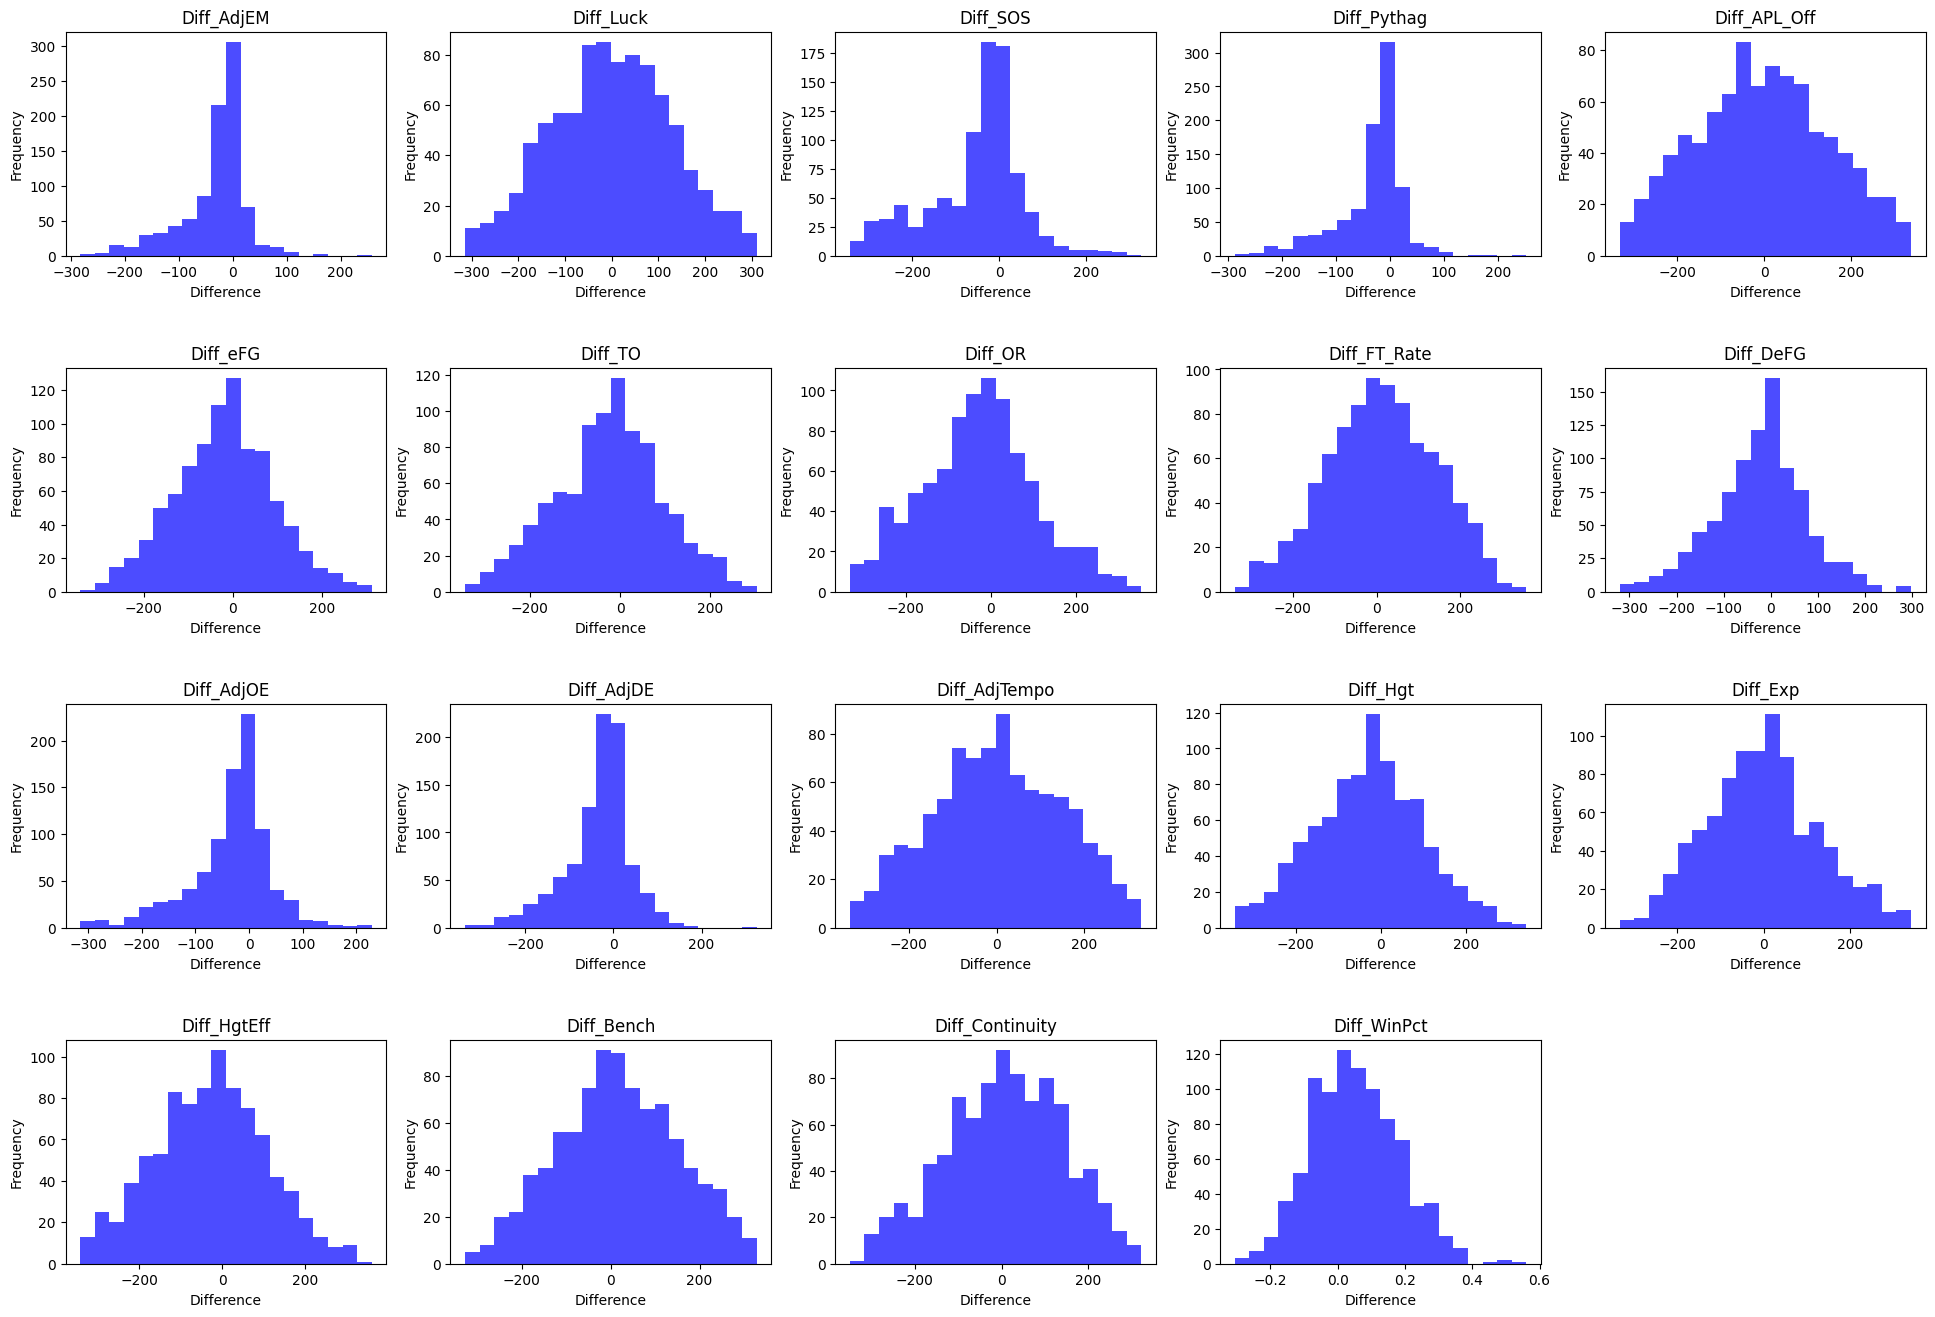

In [11]:
# generating histograms for difference features in one plot
num_cols = len(diff_cols)
cols_per_row = 5
num_rows = (num_cols + cols_per_row - 1) // cols_per_row
plt.figure(figsize=(24, num_rows * 4))
for i, col in enumerate(diff_cols):
    plt.subplot(num_rows, cols_per_row, i + 1)
    plt.hist(matchups_df[col], bins=20, color='blue', alpha=0.7)
    # adding vertical padding for space between plots
    plt.subplots_adjust(hspace=0.5)  # Adjust the value as needed for more or less space
    plt.title(col)
    plt.xlabel('Difference')
    plt.ylabel('Frequency')

- Diff AdjEM, AdjDE, AdjOE, SOS, and Pythag are pretty skewed
- This indicates that they are the biggest difference between teams that win and lose
- Must be conscious of this in feature selection and analysis

## Feature Selection

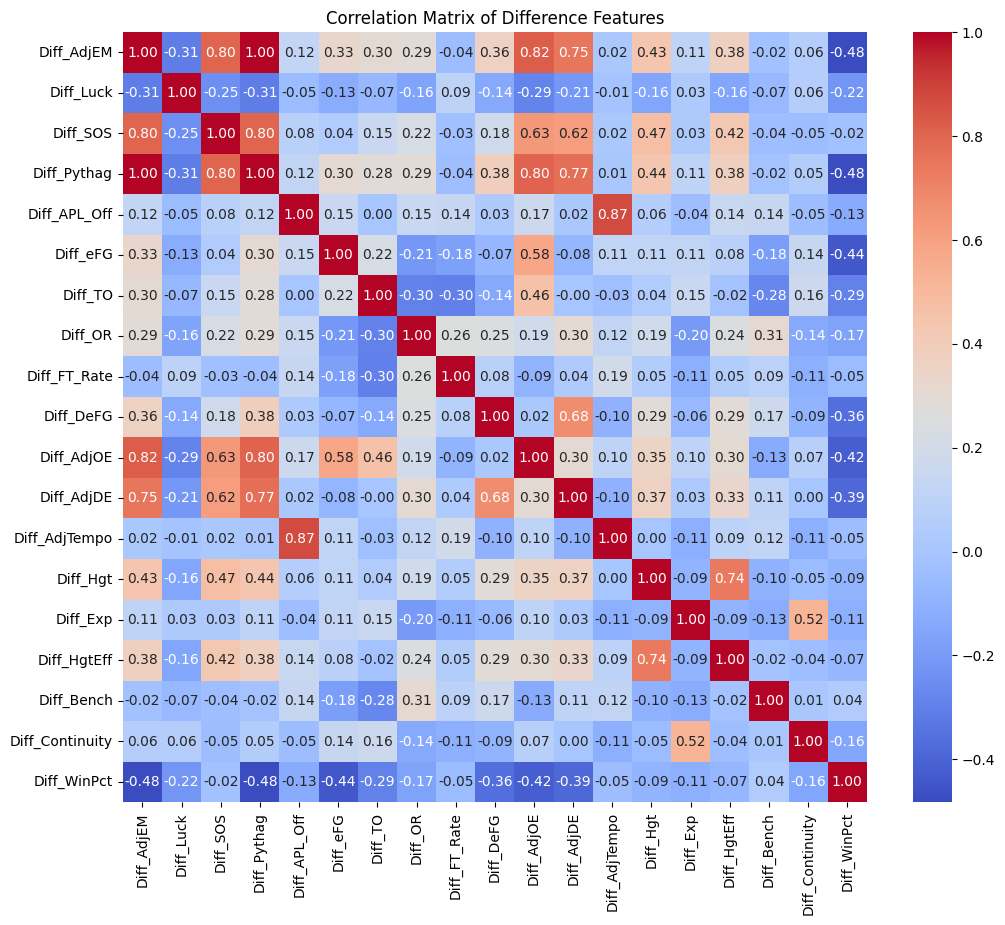

In [12]:
# correlation matrix of features
plt.figure(figsize=(12, 10))
sns.heatmap(matchups_df[diff_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix of Difference Features")
plt.show()

Not including highly correlated features in model
- Removing ADJ_EM as it is calculated based off of offensive and defensive efficiency
- Removing Pythag because it is calculated based off of efficiency as well
- Removing diff_hgt because effective height is highly correlated and more telling
- Removing average possession length because it is highly correlated with tempo 

In [13]:
features = [
    # Ratings
    "Diff_Luck",
    "Diff_SOS",

    # Four Factors
    "Diff_eFG",
    "Diff_TO",
    "Diff_OR",
    "Diff_FT_Rate",
    "Diff_DeFG",
    "Diff_AdjOE",
    "Diff_AdjDE",
    "Diff_AdjTempo",

    # Height / Roster
    "Diff_Exp",
    "Diff_HgtEff",
    "Diff_Bench",
    "Diff_Continuity",
    
    # Regular season record
    "Diff_WinPct"]

# splitting into features, target
X = matchups_df[features]
y = matchups_df["Upset"]

# ensuring correct size, no missing data
print(f"Features: {len(features)}")
print(f"Samples: {len(y)}")
print(f"\nNull counts:\n{X.isnull().sum()}")

Features: 15
Samples: 902

Null counts:
Diff_Luck          0
Diff_SOS           0
Diff_eFG           0
Diff_TO            0
Diff_OR            0
Diff_FT_Rate       0
Diff_DeFG          0
Diff_AdjOE         0
Diff_AdjDE         0
Diff_AdjTempo      0
Diff_Exp           0
Diff_HgtEff        0
Diff_Bench         0
Diff_Continuity    0
Diff_WinPct        0
dtype: int64


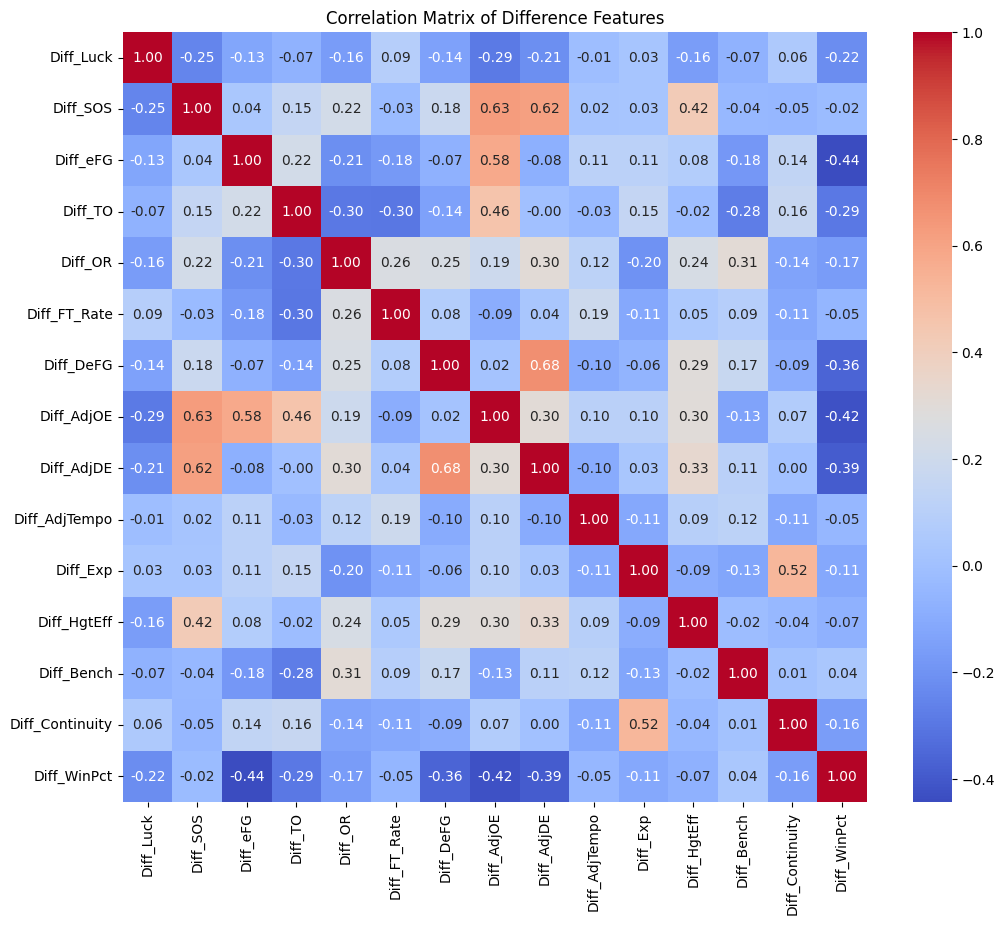

In [14]:
# re-checking for co-linearity based on selected features
plt.figure(figsize=(12, 10))
sns.heatmap(X.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix of Difference Features")
plt.show()

No longer any features that are concerningly highly correlated

## Preparing Data for Modeling

- When initially modeling was conducted, there was data leakage from the input format
- Data was formatted as winner vs. loser and upset could be detected
- Instead formatting as higher v. lower seed below

In [15]:
# favorite vs. underdog instead of winner v. loser 
matchups_reframed = matchups_df.copy()

# Identify which team is the favorite (lower seed number = better seed)
fav_is_winner = matchups_reframed["WSeed"] <= matchups_reframed["LSeed"]

# Underdog stats minus Favorite stats
for col in features:
    w_col = col.replace("Diff_", "W_Rank").replace("Diff_", "")
    # flipping sign when favorite is the winner to get underdog minus favorite
    matchups_reframed[col] = np.where(fav_is_winner, -matchups_df[col], matchups_df[col])

# adding in favorite and underdog seed and team name for reference
matchups_reframed["Fav_Seed"] = np.where(fav_is_winner, matchups_df["WSeed"], matchups_df["LSeed"])
matchups_reframed["Dog_Seed"] = np.where(fav_is_winner, matchups_df["LSeed"], matchups_df["WSeed"])
matchups_reframed["Fav_Team"] = np.where(fav_is_winner, matchups_df["WTeamName"], matchups_df["LTeamName"])
matchups_reframed["Dog_Team"] = np.where(fav_is_winner, matchups_df["LTeamName"], matchups_df["WTeamName"])
matchups_reframed["SeedDiff"] = matchups_reframed["Dog_Seed"] - matchups_reframed["Fav_Seed"]

# Target: did the underdog win? (= upset)
matchups_reframed["Upset"] = matchups_df["Upset"]

# Add SeedDiff as a feature
features_with_seed = features + ["SeedDiff"]
matchups_reframed["SeedDiff"] = matchups_reframed["Dog_Seed"] - matchups_reframed["Fav_Seed"]
X = matchups_reframed[features_with_seed]
y = matchups_reframed["Upset"]

# Means should be mainly positive since we are doing underdog minus favorite (lower rank --> better)
print(X.mean().round(2))
print(f"\nUpset rate: {y.mean():.2%}")

Diff_Luck          -5.49
Diff_SOS           68.71
Diff_eFG           27.88
Diff_TO            28.12
Diff_OR            40.03
Diff_FT_Rate       -0.62
Diff_DeFG          34.30
Diff_AdjOE         44.89
Diff_AdjDE         42.79
Diff_AdjTempo       9.11
Diff_Exp            0.63
Diff_HgtEff        48.31
Diff_Bench         -9.58
Diff_Continuity    -0.93
Diff_WinPct        -0.07
SeedDiff            6.28
dtype: float64

Upset rate: 22.39%


- Upsets occurs in a bit less than 1/4 of games overall
- Mainly positive differences for higher seeded teams (other than luck, bench utilization, actually lower win %)

Subsetting for just Underdogs (seed diff more than 1)

In [16]:
underdogs = matchups_reframed[matchups_reframed["SeedDiff"].abs() > 1].copy()

print(f"\nTotal matchups: {len(matchups_reframed)}")
print(f"Underdog matchups (|SeedDiff| > 1): {len(underdogs)}")
print(f"Upsets: {(underdogs['Upset'] == 1).sum()}  |  Non-Upsets: {(underdogs['Upset'] == 0).sum()}")


Total matchups: 902
Underdog matchups (|SeedDiff| > 1): 728
Upsets: 202  |  Non-Upsets: 526


## Upset vs. Non-Upset Differences

In [17]:
upset_games = underdogs.loc[underdogs["Upset"] == 1, features_with_seed]
non_upset_games = underdogs.loc[underdogs["Upset"] == 0, features_with_seed]

# gathering summary statistics for upsets vs. non
summary_upset = upset_games.describe().T[["mean", "50%", "std"]]
summary_non_upset = non_upset_games.describe().T[["mean", "50%", "std"]]

summary_upset.columns  = ["Upset_Mean", "Upset_Median", "Upset_Std"]
summary_non_upset.columns = ["NonUpset_Mean", "NonUpset_Median", "NonUpset_Std"]

# adding seed diff
comparison = pd.concat([summary_upset, summary_non_upset], axis=1)
comparison["Mean_Diff"] = comparison["Upset_Mean"] - comparison["NonUpset_Mean"]

print("\n── Profile Comparison: Upset vs Non-Upset Underdogs ──")
print(comparison.round(2).to_string())


── Profile Comparison: Upset vs Non-Upset Underdogs ──
                 Upset_Mean  Upset_Median  Upset_Std  NonUpset_Mean  NonUpset_Median  NonUpset_Std  Mean_Diff
Diff_Luck            -13.06         -7.00     133.61          -7.23            -11.5        125.92      -5.83
Diff_SOS              33.51         13.00      80.90         103.77             76.0        108.05     -70.26
Diff_eFG              17.52         16.50     110.88          37.29             29.0        110.32     -19.77
Diff_TO                9.00         -1.00     114.62          40.01             31.0        117.07     -31.01
Diff_OR               25.69         26.00     131.90          54.72             49.0        127.97     -29.02
Diff_FT_Rate          18.08         11.50     125.77          -7.59            -12.0        131.11      25.67
Diff_DeFG             19.11         13.00      95.08          47.46             38.0         94.25     -28.35
Diff_AdjOE            25.80         20.00      55.27          64

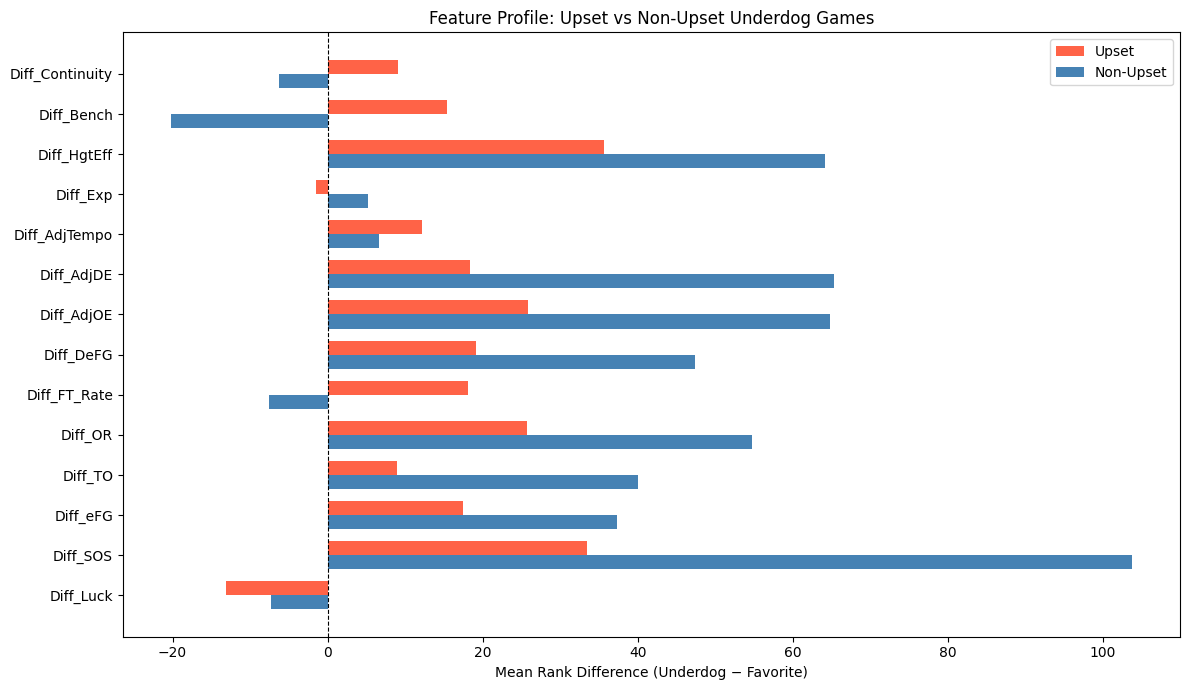

In [18]:
# removing seed diff and win %, different scales
plotting_features = [feat for feat in features_with_seed if feat not in ["SeedDiff", "Diff_WinPct"]]
comparison_plot = comparison.loc[plotting_features]

fig, ax = plt.subplots(figsize=(12, 7))
x = range(len(plotting_features))
width = 0.35
ax.barh([i + width/2 for i in x], comparison_plot["Upset_Mean"], width, label="Upset", color="tomato")
ax.barh([i - width/2 for i in x], comparison_plot["NonUpset_Mean"], width, label="Non-Upset", color="steelblue")
ax.set_yticks(list(x))
ax.set_yticklabels(plotting_features)
ax.set_xlabel("Mean Rank Difference (Underdog − Favorite)")
ax.set_title("Feature Profile: Upset vs Non-Upset Underdog Games")
ax.legend()
ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
plt.tight_layout()
plt.show()

The biggest differences between upsets and non-upsets are
- Strength of Schedule: Teams that upset have an average of 70 ranks harder SOS than non-upset teams
- Adjusted Defensive Efficiency: Teams that upset have an average of 47 ranks higher adjusted defensive efficiency than non-upset teams
- Bench Utilization: Teams that upset use their bench an average of 36 ranks less than non-upset teams
- Turnover Difference: Teams that upset are ranked 31 slots higher, on average, in turnover differential than non-upset teams
- Teams that upset are approximately 2 seeds higher, on average, than non-upset teams

## Modeling

### Performing Clustering

In [19]:
# scaling features so Kmeans treats with equal importance
scaler = StandardScaler()
X_scaled = scaler.fit_transform(underdogs[features_with_seed])

kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
underdogs = underdogs.copy()
underdogs["Cluster"] = kmeans.fit_predict(X_scaled)

# Cluster upset rates
cluster_summary = underdogs.groupby("Cluster").agg(
    n_games=("Upset", "count"),
    n_upsets=("Upset", "sum"),
    upset_rate=("Upset", "mean")
).reset_index()
cluster_summary["upset_rate_pct"] = (cluster_summary["upset_rate"] * 100).round(1)

# Cluster centers
cluster_zscores = pd.DataFrame(kmeans.cluster_centers_, columns=features_with_seed)
cluster_zscores.index.name = "Cluster"

# transforming cluster centers back to original scale for interpretation
cluster_profiles = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=features_with_seed
).round(2)
cluster_profiles.index.name = "Cluster"

### Generating Labels for Clusters

In [20]:
# more interpretable feature names
label_map = {
    "Diff_Luck": "Luck", "Diff_SOS": "Strength of Schedule",
    "Diff_eFG": "Effective FG%", "Diff_TO": "Turnover Rate",
    "Diff_OR": "Off. Rebounding", "Diff_FT_Rate": "FT Rate",
    "Diff_DeFG": "Def. eFG%", "Diff_AdjOE": "Adj. Off. Efficiency",
    "Diff_AdjDE": "Adj. Def. Efficiency", "Diff_AdjTempo": "Tempo",
    "Diff_Exp": "Experience", "Diff_HgtEff": "Height Efficiency",
    "Diff_Bench": "Bench Depth", "Diff_Continuity": "Continuity",
 "Diff_WinPct": "Win %", "SeedDiff": "Seed Gap"
}

# looping over clusters, looking at top 3 defining features, labeling (based on z-scores)
cluster_descriptions = {}
for cid in range(kmeans.n_clusters):
    row = cluster_zscores.loc[cid]
    top = row.abs().sort_values(ascending=False).head(3)
    
    strengths = []
    weaknesses = []
    for feat in top.index:
        name = label_map.get(feat, feat)
        # For rank-based features: negative z = underdog ranked BETTER than avg favorite (strength)
        if feat in ["Diff_WinPct"]:
            if row[feat] > 0:
                strengths.append(name)
            else:
                weaknesses.append(name)
        elif feat == "SeedDiff":
            if row[feat] > 0:
                weaknesses.append(f"Large {name}")
            else:
                strengths.append(f"Small {name}")
        else:
            # Rank diffs: negative = underdog closer to favorite
            if row[feat] < 0:
                strengths.append(name)
            else:
                weaknesses.append(name)
    
    # formatting text description
    parts = []
    if strengths:
        parts.append("Strong: " + ", ".join(strengths))
    if weaknesses:
        parts.append("Weak: " + ", ".join(weaknesses))
    
    desc = "\n".join(parts)
    cluster_descriptions[cid] = desc

print("── Cluster Descriptions ──")
for cid, desc in cluster_descriptions.items():
    print(f"\nCluster {cid} (n={cluster_summary.loc[cid, 'n_games']}, "
          f"upset={cluster_summary.loc[cid, 'upset_rate_pct']}%):")
    print(f"  {desc}")

── Cluster Descriptions ──

Cluster 0 (n=148, upset=29.1%):
  Strong: Win %, Luck, Def. eFG%

Cluster 1 (n=89, upset=10.1%):
  Weak: Adj. Def. Efficiency, Strength of Schedule, Large Seed Gap

Cluster 2 (n=82, upset=6.1%):
  Weak: Adj. Off. Efficiency, Large Seed Gap, Strength of Schedule

Cluster 3 (n=202, upset=40.6%):
  Strong: Turnover Rate, Adj. Off. Efficiency
Weak: FT Rate

Cluster 4 (n=207, upset=30.4%):
  Strong: Strength of Schedule, Off. Rebounding
Weak: Luck


### EXAMPLE GAMES PER CLUSTER

In [21]:
display_cols = ["Season", "Dog_Team", "Dog_Seed", "Fav_Team", "Fav_Seed", "Upset", "Cluster"]

# outputting example games from each cluster to illustrate the profiles (sorted by most recent season)
print("\n── Example Games Per Cluster ──")
for cid in range(kmeans.n_clusters):
    cluster_games = underdogs[underdogs["Cluster"] == cid].sort_values("Season", ascending=False)
    n_show = min(10, len(cluster_games))
    print(f"\n{'='*70}")
    print(f"CLUSTER {cid}: {cluster_descriptions[cid]}")
    print(f"Upset Rate: {cluster_summary.loc[cid, 'upset_rate_pct']}% | "
          f"Games: {cluster_summary.loc[cid, 'n_games']}")
    print(f"{'='*70}")
    print(cluster_games[display_cols].head(n_show).to_string(index=False))



── Example Games Per Cluster ──

CLUSTER 0: Strong: Win %, Luck, Def. eFG%
Upset Rate: 29.1% | Games: 148
 Season      Dog_Team  Dog_Seed  Fav_Team  Fav_Seed  Upset  Cluster
   2024 James Madison        12 Wisconsin         5      1        0
   2024   McNeese St.        12   Gonzaga         5      0        0
   2024      Duquesne        11       BYU         6      1        0
   2024       Colgate        14    Baylor         3      0        0
   2024    N.C. State        11      Duke         4      1        0
   2024      Duquesne        11  Illinois         3      0        0
   2024 James Madison        12      Duke         4      0        0
   2024       Oakland        14  Kentucky         3      1        0
   2024  Grand Canyon        12   Alabama         4      0        0
   2024  Morehead St.        14  Illinois         3      0        0

CLUSTER 1: Weak: Adj. Def. Efficiency, Strength of Schedule, Large Seed Gap
Upset Rate: 10.1% | Games: 89
 Season               Dog_Team  Dog_Se

In [22]:
# finding average seed for each cluster (of underdog)
cluster_seed_summary = underdogs.groupby("Cluster").agg(
    avg_dog_seed=("Dog_Seed", "mean"),
    avg_fav_seed=("Fav_Seed", "mean"),
    avg_seed_diff=("SeedDiff", "mean")
).round(2)

In [23]:
cluster_seed_summary

,avg_dog_seed,avg_fav_seed,avg_seed_diff
Cluster,,,
0,11.14,4.28,6.85
1,14.38,2.76,11.62
2,15.34,1.74,13.60
3,9.61,3.61,6.00
4,8.68,3.14,5.55


There are clearly differences in seed for each cluster. Cluster 2(with an upset rate of 6.1%) has an average seed of 15.34, indicating that this is likely mainly 15/16 seeds with virtually no chance of winning

### Defining Features

In [24]:
print("\n── Top 5 Defining Features Per Cluster ──")
for cid in range(kmeans.n_clusters):
    row = cluster_zscores.loc[cid]
    top = row.abs().sort_values(ascending=False).head(5)
    print(f"\nCluster {cid} (n={cluster_summary.loc[cid, 'n_games']}, "
          f"upset rate={cluster_summary.loc[cid, 'upset_rate_pct']}%):")
    for feat in top.index:
        direction = "↑" if row[feat] > 0 else "↓"
        print(f"  {direction} {label_map.get(feat, feat)}: {row[feat]:.2f}")
print("\n\n" + "="*80)


── Top 5 Defining Features Per Cluster ──

Cluster 0 (n=148, upset rate=29.1%):
  ↑ Win %: 0.89
  ↓ Luck: -0.67
  ↓ Def. eFG%: -0.67
  ↓ Adj. Def. Efficiency: -0.53
  ↓ FT Rate: -0.33

Cluster 1 (n=89, upset rate=10.1%):
  ↑ Adj. Def. Efficiency: 1.62
  ↑ Strength of Schedule: 1.12
  ↑ Seed Gap: 1.09
  ↑ Def. eFG%: 1.08
  ↓ Effective FG%: -0.55

Cluster 2 (n=82, upset rate=6.1%):
  ↑ Adj. Off. Efficiency: 2.02
  ↑ Seed Gap: 1.63
  ↑ Strength of Schedule: 1.25
  ↑ Effective FG%: 1.14
  ↓ Win %: -0.95

Cluster 3 (n=202, upset rate=40.6%):
  ↓ Turnover Rate: -0.85
  ↑ FT Rate: 0.66
  ↓ Adj. Off. Efficiency: -0.63
  ↑ Off. Rebounding: 0.61
  ↓ Effective FG%: -0.59

Cluster 4 (n=207, upset rate=30.4%):
  ↓ Strength of Schedule: -0.82
  ↓ Off. Rebounding: -0.65
  ↑ Luck: 0.59
  ↓ Height Efficiency: -0.56
  ↓ Seed Gap: -0.55




- Cluster 0: High win %, Luck, Def eFG%
  - Unlucky Winners
- Cluster 1: Big gap in seeds, low def efficiency, weak SOS
  - WEAK COMPETITION TEAMS
- Cluster 2: Really bad efficiencies, large seed gap
  - BOTTOM OF THE BARREL
- Cluster 3: Big turnover gap rate (strong), adjusted offensive efficiency, effective field goal %
  - HIGH POWERED OFFENSES 
- Cluster 4: Strong strength of schedule, weak luck
  - Unlucky big conference teams

## Final Press Release Plots

### Rationale

 The two visualizations I decided to generate for my final report were bar charts showing the statistical profiles of underdogs that were clustered together. This was an iterative process, trying many different visualizations that showed different insights. In the end I settled on using horizontal bar charts because I felt they were interpretable, illustrative, and most importantly they addressed my initial exploration question - what statistical profiles are shared among teams that pull off upsets in March Madness? This visualization clearly shows the metrics shared by teams in each cluster as well as the upset rate within each cluster, illustrating differences that separate teams. I experimented with radar charts but found they were too cluttered and complicated for 5 clusters.

 My second plot shows feature importance based on z-score variance across clusters. If a feature's center value is very different across clusters then it is an important determinant of cluster assignment. If it is very similar across clusters, it is not that important. I chose to include this plot as well because I felt it did a strong job of illustrating the metrics that are most important to clusters, and therefore upsets.

### Plot 1: Bar Charts

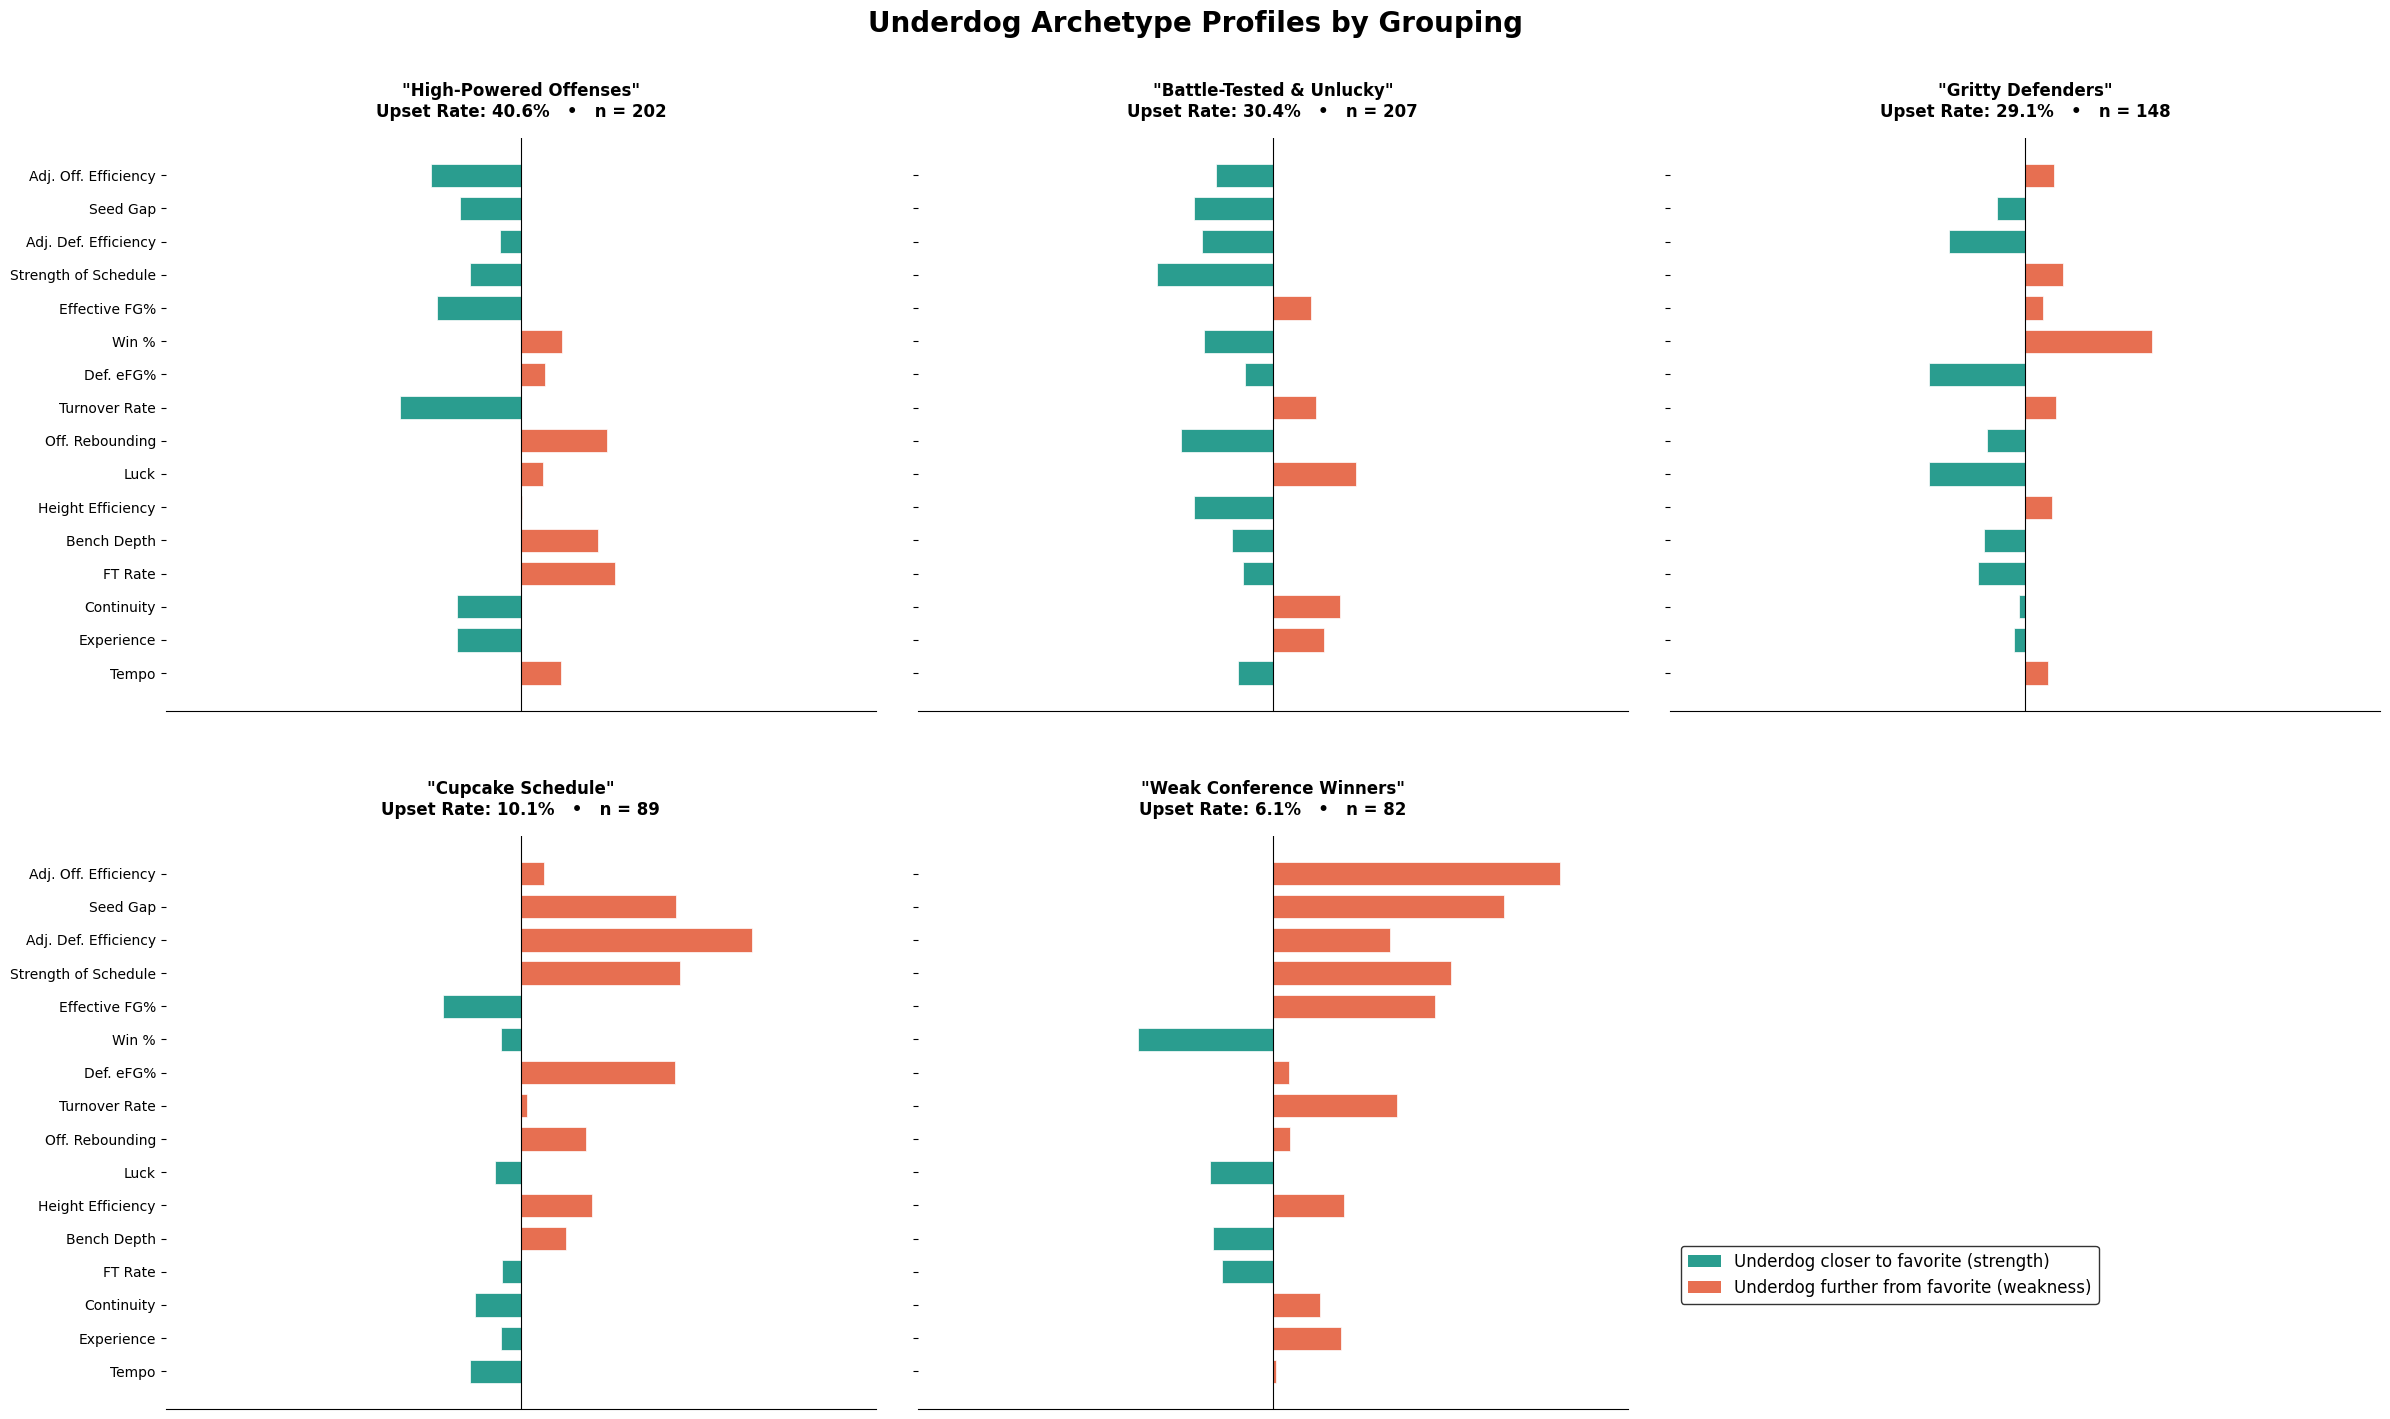

In [33]:
# Cluster names
cluster_names = {
    0: "Gritty Defenders",
    1: "Cupcake Schedule",
    2: "Weak Conference Winners",
    3: "High-Powered Offenses",
    4: "Battle-Tested & Unlucky"
}

fig, axes = plt.subplots(2, 3, figsize=(24, 14))
axes_flat = axes.flatten()

# ordering feature importance by z-scores (most extreme = most defining for the cluster)
feat_order = cluster_zscores.var(axis=0).sort_values(ascending=False).index.tolist()
radar_labels_sorted = [label_map.get(f, f) for f in feat_order]

# looping over clusters to create horizontal bar charts of z-scores for top features, colored by strength vs. weakness

# sorting clusters by upset rate
sorted_clusters = cluster_summary.sort_values("upset_rate", ascending=False)["Cluster"].tolist()
for i, cid in enumerate(sorted_clusters):
    ax = axes_flat[i]
    vals = cluster_zscores.loc[cid, feat_order].values
    colors = ["#2a9d8f" if v < 0 else "#e76f51" for v in vals]

    ax.barh(radar_labels_sorted[::-1], vals[::-1], color=colors[::-1],
            edgecolor="white", linewidth=0.5, height=0.7)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_xlim(-2.5, 2.5)
    ax.tick_params(axis="y", labelsize=10)
    ax.tick_params(axis="x", labelsize=0)
    # removing x axis labels and ticks for cleaner look
    ax.set_xticks([])
    # removing x axis lines
    ax.spines["bottom"].set_visible(False)

    ax.set_title(
        f'"{cluster_names[cid]}"\n'
        f"Upset Rate: {cluster_summary.loc[cid, 'upset_rate_pct']}%   •   "
        f"n = {cluster_summary.loc[cid, 'n_games']}",
        fontsize=12, fontweight="bold", pad=15
    )

    if i % 3 != 0:
        ax.set_yticklabels([])

    sns.despine(ax=ax, left=True)

axes_flat[5].set_visible(False)

# adding key for color coding (strength vs. weakness)
legend_elements = [
    Patch(facecolor="#2a9d8f", label="Underdog closer to favorite (strength)"),
    Patch(facecolor="#e76f51", label="Underdog further from favorite (weakness)")
]
fig.legend(handles=legend_elements, loc="lower right", fontsize=12,
           bbox_to_anchor=(0.88, 0.08), frameon=True, edgecolor="black")

fig.suptitle("Underdog Archetype Profiles by Grouping",
             fontsize=20, fontweight="bold", y=1.01)
plt.tight_layout(h_pad=5, w_pad=3)
plt.show()

In [34]:
fig.subplots_adjust(top=0.92)
fig.savefig("../../figures/archetype_profiles.png", dpi=300, bbox_inches="tight")

### Plot 2: Feature Importance

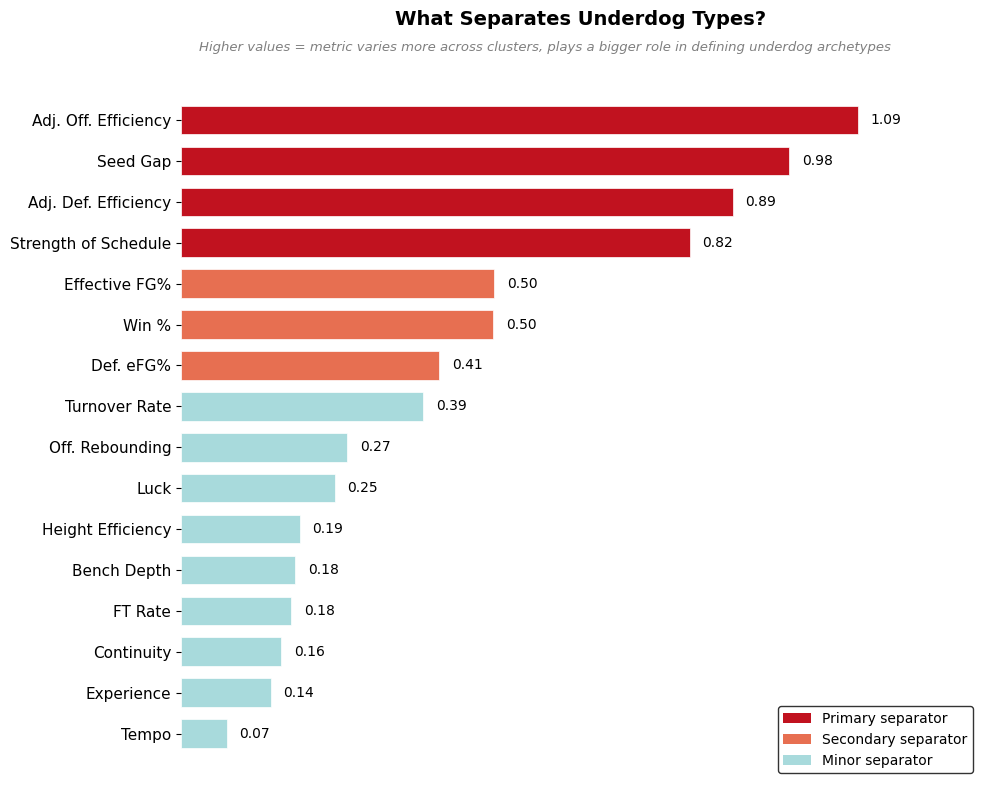

In [27]:
fig, ax = plt.subplots(figsize=(10, 8))

center_variance = cluster_zscores.var(axis=0).sort_values(ascending=True)
friendly_labels = [label_map.get(f, f) for f in center_variance.index]

# Tier-based coloring
tier_colors = []
for val in center_variance.values:
    if val >= 0.8:
        tier_colors.append("#c1121f")   # red — top tier
    elif val >= 0.4:
        tier_colors.append("#e76f51")   # orange — mid tier
    else:
        tier_colors.append("#a8dadc")   # light blue — low tier

# horizontal bar chart of variance
bars = ax.barh(friendly_labels, center_variance.values, color=tier_colors,
               edgecolor="white", linewidth=0.5, height=0.7)

for bar, val in zip(bars, center_variance.values):
    ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
            f"{val:.2f}", va="center", fontsize=10, color="black")

ax.set_xlim(0, center_variance.max() * 1.18)
ax.set_xlabel("")
ax.tick_params(axis="y", labelsize=11)
ax.tick_params(axis="x", labelsize=0)
ax.xaxis.set_visible(False)

ax.set_title(
    "What Separates Underdog Types?",
    fontsize=14, fontweight="bold", pad=35
)
fig.text(
    0.55, 0.93,
    "Higher values = metric varies more across clusters, plays a bigger role in defining underdog archetypes",
    ha="center", fontsize=9.5, fontstyle="italic", color="grey"
)

# Tier legend
from matplotlib.patches import Patch
tier_legend = [
    Patch(facecolor="#c1121f", label="Primary separator"),
    Patch(facecolor="#e76f51", label="Secondary separator"),
    Patch(facecolor="#a8dadc", label="Minor separator")
]
ax.legend(handles=tier_legend, loc="lower right", fontsize=10,
          frameon=True, edgecolor="black")

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

In [28]:
# saving plots to plots directory
fig.savefig("../../figures/feature_importance.png", dpi=300)